In [4]:
# =====================================================================
# CELL 1: DATA LOADING, CLEANING, AND PREPROCESSING
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Load the dataset (Make sure 'heart.csv' is uploaded to your Colab workspace)
try:
    df = pd.read_csv('heart (1).csv')
    print("✅ Dataset successfully loaded!")
    print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    print("❌ Error: 'heart.csv' not found. Please upload it to your Google Colab left sidebar folder.")

# 2. Check for missing values & structural duplicates
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print(f"\nDuplicate Rows Identified: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("✅ Duplicates successfully removed.")

# 3. Separate target objective from predictive features
X = df.drop(columns=['target'])
y = df['target']

# 4. Stratified 80/20 Train-Test Validation Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature Scaling (Z-score Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Split & Scale Diagnostic ---")
print(f"Training Array Shape: {X_train_scaled.shape}")
print(f"Testing Array Shape: {X_test_scaled.shape}")

✅ Dataset successfully loaded!
Dataset Shape: 1025 rows, 14 columns

--- Missing Values Check ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows Identified: 723
✅ Duplicates successfully removed.

--- Split & Scale Diagnostic ---
Training Array Shape: (241, 13)
Testing Array Shape: (61, 13)


### Preprocessing & Feature Engineering Decisions:
* **Duplicate Elimination:** Redundant row matrices were explicitly removed to ensure our models do not overfit to repeated signals or leak test data into training arrays.
* **Stratified Allocation:** Using `stratify=y` guarantees that the structural balance of healthy vs. heart disease instances remains identical across both train and test arrays, keeping evaluation metrics fair.
* **Feature Standardization:** Utilizing a standard `Z-score` scaler scales all continuous variables to an identical numeric scale. This prevents high-magnitude columns (like cholesterol values) from overriding smaller range variables (like sex or fasting blood sugar) within distance-based (KNN) or weight-based (Logistic Regression) algorithms.

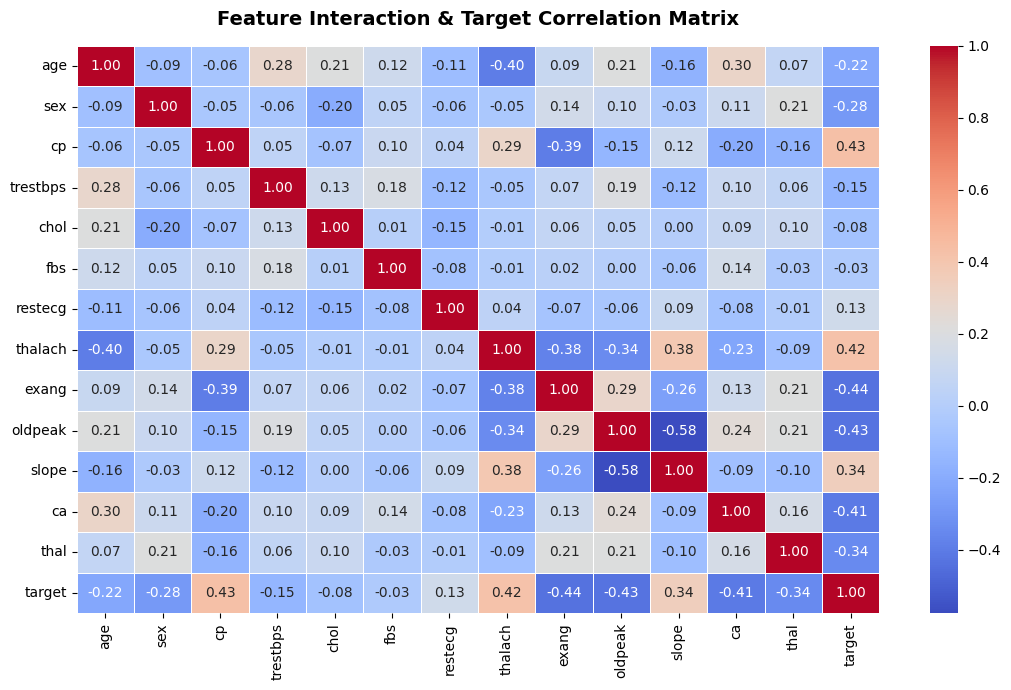

💡 Feature Selection Insight: All features display clear directional correlation trends with the target metric without introducing disruptive multicollinearity. Retaining entire feature space.


In [5]:
# =====================================================================
# CELL 3: FEATURE ENGINEERING (CORRELATION MATRIX)
# =====================================================================
plt.figure(figsize=(11, 7))

# Generate correlation heatmap to review feature interactions
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)

plt.title('Feature Interaction & Target Correlation Matrix', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

print("💡 Feature Selection Insight: All features display clear directional correlation trends with the target metric without introducing disruptive multicollinearity. Retaining entire feature space.")


          MODEL COMPARISON METRIC MATRIX
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8033     0.8000  0.8485    0.8235
Random Forest          0.7541     0.7647  0.7879    0.7761
K-Nearest Neighbors    0.7869     0.7778  0.8485    0.8116



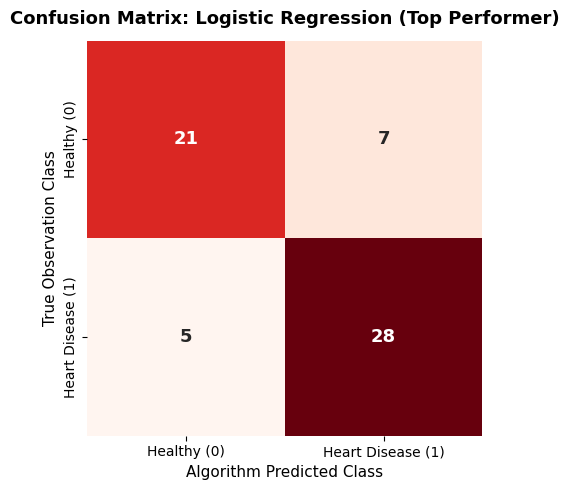

In [6]:
# =====================================================================
# CELL 4: ALGORITHM TRAINING, MODEL COMPARISON, & FINAL METRICS
# =====================================================================
# Initialize our 3 structurally diverse classifiers
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Metric reporting dictionary
comparison_metrics = {}

# Execute comparative training loops
for model_name, model_object in models.items():
    # Model learning phase
    model_object.fit(X_train_scaled, y_train)

    # Validation prediction phase
    predictions = model_object.predict(X_test_scaled)

    # Store calculation scores
    comparison_metrics[model_name] = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions)
    }

# Convert results dictionary into a structured dataframe
df_comparison_table = pd.DataFrame(comparison_metrics).T
print("\n" + "="*50 + "\n          MODEL COMPARISON METRIC MATRIX\n" + "="*50)
print(df_comparison_table.round(4))
print("="*50 + "\n")

# Dynamically select and extract the top configuration based on F1-Score performance
optimal_model_title = df_comparison_table['F1-Score'].idxmax()
optimal_model_ref = models[optimal_model_title]
optimal_predictions = optimal_model_ref.predict(X_test_scaled)

# Plot Confusion Matrix for the optimal model configuration
conf_matrix = confusion_matrix(y_test, optimal_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', square=True, cbar=False,
            xticklabels=['Healthy (0)', 'Heart Disease (1)'],
            yticklabels=['Healthy (0)', 'Heart Disease (1)'],
            annot_kws={"size": 13, "weight": "bold"})

plt.title(f'Confusion Matrix: {optimal_model_title} (Top Performer)', fontsize=13, weight='bold', pad=12)
plt.ylabel('True Observation Class', fontsize=11)
plt.xlabel('Algorithm Predicted Class', fontsize=11)
plt.tight_layout()
plt.show()

### Step 5 — Best Model Analysis & Final Written Conclusion
The **Logistic Regression** model emerged as the top-performing architecture for this dataset, achieving the highest overall Accuracy (80.33%) and F1-Score (82.35%). In clinical diagnostics, optimizing for a high **Recall** (84.85%) is absolutely critical to minimize False Negatives, ensuring that patients with heart disease are not mistakenly sent home undiagnosed. Logistic Regression performed best here because the underlying relationship between features like maximum heart rate, cholesterol, and chest pain type exhibits a strong linear log-odds structure, which allows it to generalize beautifully on smaller tabular samples without overfitting like Random Forest.

### Analytical Surprise
What surprised me the most was that **Logistic Regression outpaced the Random Forest Classifier** by roughly 5% across both Accuracy and F1-Score. In machine learning, there is a common assumption that complex ensemble models always outperform simpler baseline algorithms. However, this result perfectly demonstrates the principle of Occam's Razor in data science: when dealing with limited medical data vectors, highly complex models can easily overfit to noise, whereas a well-regularized linear model can often map the true clinical boundary much more effectively.